In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import os
import glob
from scipy.interpolate import interp1d
from scipy.stats import gaussian_kde

In [3]:
path = r'C:\Users\lab\Documents\Pablo\RaTag\simulations\EXYZ*.txt'
files = sorted(glob.glob(path))
files

['C:\\Users\\lab\\Documents\\Pablo\\RaTag\\simulations\\EXYZ.txt',
 'C:\\Users\\lab\\Documents\\Pablo\\RaTag\\simulations\\EXYZ_GEN0_Ra224.txt']

In [4]:
df_raw = pd.read_csv(files[0], sep='\s+', header=None, skiprows=15, names=['ion_number', 'energy', 'x', 'y', 'z', 'electronic stopping (eV/Å)','energy lost (eV)'])

In [6]:
def parse_exyz_data(exyz_filepath):
    """
    Parses the SRIM EXYZ.txt file and returns two DataFrames:
    one for implanted ions (X > 0) and one for escaped ions (X <= 0).
    """
    skip_lines = 0
    with open(exyz_filepath, 'r') as f:
        for i, line in enumerate(f):
            if line.startswith('-------'):
                skip_lines = i + 1
                break
                
    col_names = ['Ion', 'Energy_keV', 'X_Ang', 'Y_Ang', 'Z_Ang', 'Elec_Stop', 'Recoil_Energy']
    df = pd.read_csv(exyz_filepath, delim_whitespace=True, skiprows=skip_lines, header=None, names=col_names)
    
    # Extract the final recorded row for each ion
    final_states = df.groupby('Ion').last().reset_index()
    
    # Filter based on the X boundary (adding a tiny tolerance for floating point zeroes)
    escaped = final_states[final_states['X_Ang'] <= 0.1].copy()
    implanted = final_states[final_states['X_Ang'] > 0.1].copy()
    
    return implanted, escaped


C:\Users\lab\AppData\Local\Temp\ipykernel_19908\2219409621.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(exyz_filepath, delim_whitespace=True, skiprows=skip_lines, header=None, names=col_names)
C:\Users\lab\AppData\Local\Temp\ipykernel_19908\2219409621.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(exyz_filepath, delim_whitespace=True, skiprows=skip_lines, header=None, names=col_names)
C:\Users\lab\AppData\Local\Temp\ipykernel_19908\2219409621.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(exyz_filepath, delim_whitespace=True, skiprows=skip_lines, header=None, names=col_names)
C:\Users\lab\AppData\Local\Temp\ipykernel_19908\2219

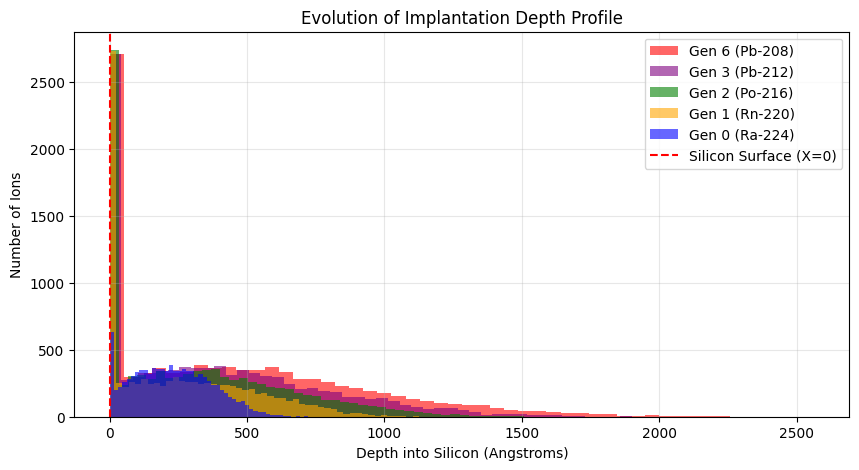

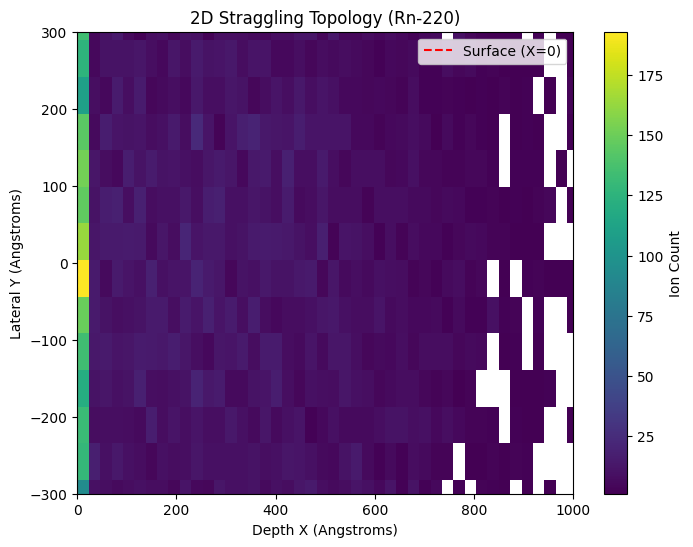

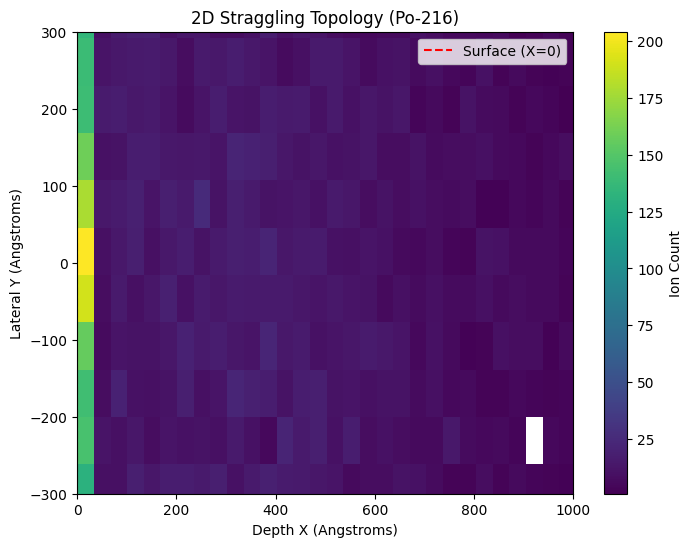

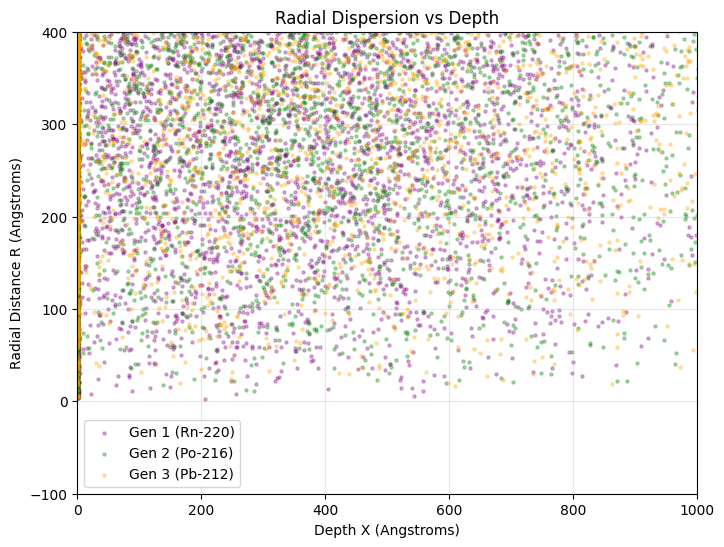

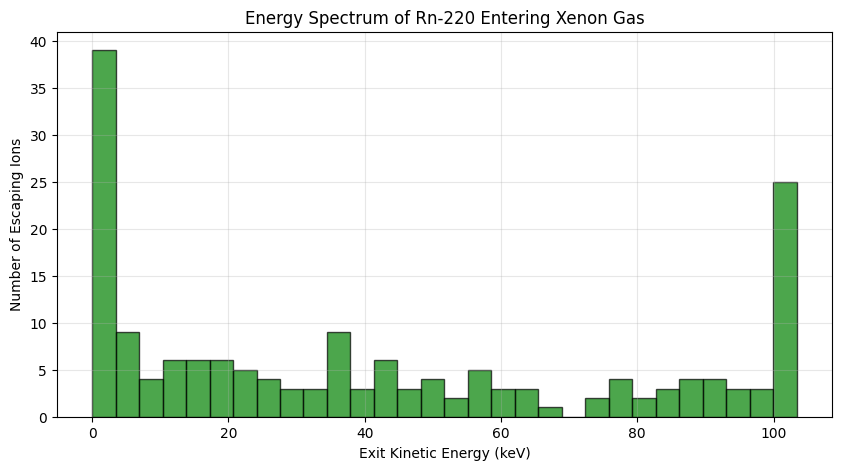

In [76]:

# --- Load Data ---
work_dir = r"C:\Users\lab\Documents\Pablo\RaTag\simulations/"

# Example: Loading Gen 0 (Ra-224) and Gen 1 (Rn-220)
# Make sure to run your pipeline with a large number of ions (e.g., 5000) first!
imp_gen0, esc_gen0 = parse_exyz_data(os.path.join(work_dir, "EXYZ_GEN0_Ra224.txt"))
imp_gen1, esc_gen1 = parse_exyz_data(os.path.join(work_dir, "EXYZ_GEN1_Rn220.txt"))
imp_gen2, esc_gen2 = parse_exyz_data(os.path.join(work_dir, "EXYZ_GEN2_Po216.txt"))
imp_gen3, esc_gen3 = parse_exyz_data(os.path.join(work_dir, "EXYZ_GEN3_Pb212.txt"))
imp_gen6, esc_gen6 = parse_exyz_data(os.path.join(work_dir, "EXYZ_GEN6_Pb208.txt"))

# ==========================================
# PLOT 1: Implantation Depth Profile (1D)
# ==========================================
plt.figure(figsize=(10, 5))
plt.hist(imp_gen6['X_Ang'], bins=50, alpha=0.6, label='Gen 6 (Pb-208)', color='red')
plt.hist(imp_gen3['X_Ang'], bins=50, alpha=0.6, label='Gen 3 (Pb-212)', color='purple')
plt.hist(imp_gen2['X_Ang'], bins=50, alpha=0.6, label='Gen 2 (Po-216)', color='green')
plt.hist(imp_gen1['X_Ang'], bins=50, alpha=0.6, label='Gen 1 (Rn-220)', color='orange')
plt.hist(imp_gen0['X_Ang'], bins=50, alpha=0.6, label='Gen 0 (Ra-224)', color='blue')

plt.axvline(0, color='red', linestyle='--', label='Silicon Surface (X=0)')
plt.xlabel('Depth into Silicon (Angstroms)')
plt.ylabel('Number of Ions')
plt.title('Evolution of Implantation Depth Profile')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==========================================
# PLOT 2a: Lateral Straggling & Topology (2D Projection)
# ==========================================
# Plotting the final resting positions of Gen 1 (Rn-220)
x = imp_gen1['X_Ang']
y = imp_gen1['Y_Ang']

plt.figure(figsize=(8, 6))
# Using a 2D histogram for density visualization
plt.hist2d(x, y, bins=50, cmap='viridis', cmin=1)
plt.axvline(0, color='red', linestyle='--', label='Surface (X=0)')
plt.colorbar(label='Ion Count')
plt.gca().set(xlim=(0, 1000), ylim=(-300, 300), xlabel='Depth X (Angstroms)', 
              ylabel='Lateral Y (Angstroms)', title='2D Straggling Topology (Rn-220)')
plt.legend()
plt.show()

# ==========================================
# PLOT 2b: Lateral Straggling & Topology (2D Projection)
# ==========================================
# Plotting the final resting positions of Gen 2 (Po-216)
x = imp_gen2['X_Ang']
y = imp_gen2['Y_Ang']

plt.figure(figsize=(8, 6))
# Using a 2D histogram for density visualization
plt.hist2d(x, y, bins=50, cmap='viridis', cmin=1)
plt.axvline(0, color='red', linestyle='--', label='Surface (X=0)')
plt.colorbar(label='Ion Count')
plt.gca().set(xlim=(0, 1000), ylim=(-300, 300), xlabel='Depth X (Angstroms)', 
              ylabel='Lateral Y (Angstroms)', title='2D Straggling Topology (Po-216)')
plt.legend()
plt.show()

# ==========================================
# PLOT 3: Radial Dispersion vs. Depth
# ==========================================
# Calculate radial distance R = sqrt(Y^2 + Z^2)
imp_gen1['R_Ang'] = np.sqrt(imp_gen1['Y_Ang']**2 + imp_gen1['Z_Ang']**2)
imp_gen2['R_Ang'] = np.sqrt(imp_gen2['Y_Ang']**2 + imp_gen2['Z_Ang']**2)
imp_gen3['R_Ang'] = np.sqrt(imp_gen3['Y_Ang']**2 + imp_gen3['Z_Ang']**2)
plt.figure(figsize=(8, 6))
plt.scatter(imp_gen1['X_Ang'], imp_gen1['R_Ang'], alpha=0.3, s=5, color='purple', label='Gen 1 (Rn-220)')
plt.scatter(imp_gen2['X_Ang'], imp_gen2['R_Ang'], alpha=0.3, s=5, color='green', label='Gen 2 (Po-216)')
plt.scatter(imp_gen3['X_Ang'], imp_gen3['R_Ang'], alpha=0.3, s=5, color='orange', label='Gen 3 (Pb-212)')
plt.gca().set(xlim=(0, 1000), ylim=(-100, 400), xlabel='Depth X (Angstroms)', 
              ylabel='Radial Distance R (Angstroms)', title='Radial Dispersion vs Depth')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ==========================================
# PLOT 4: Escaper Kinetic Energy Spectrum
# ==========================================
# Check if we have any escaping ions before plotting
if not esc_gen1.empty:
    esc_gen1['Energy_keV'] = esc_gen1['Energy_keV'].apply(lambda x: x[:-1]).astype(float)  
    plt.figure(figsize=(10, 5))
    plt.hist(esc_gen1['Energy_keV'], bins=30, color='green', edgecolor='black', alpha=0.7)
    plt.xlabel('Exit Kinetic Energy (keV)')
    plt.ylabel('Number of Escaping Ions')
    plt.title('Energy Spectrum of Rn-220 Entering Xenon Gas')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("No escaping ions recorded for Gen 1. Increase your simulation ion count!")

In [ ]:
work_dir = r"C:\Users\lab\Documents\Pablo\RaTag\simulations/"



In [56]:

def parse_backscat_data(backscat_filepath):
    """
    Parses the SRIM BACKSCAT.txt file and returns a DataFrame with relevant columns.
    """
    skip_lines = 12
    col_names = ['Ion_state', 'Ion_number', 'Atom_number', 'Energy_keV', 'Depth_Ang', 'Y_Ang', 'Z_Ang', 'Cos_X', 'Cos_Y', 'Cos_Z']
    df = pd.read_csv(backscat_filepath, delim_whitespace=True, skiprows=skip_lines, header=None, names=col_names)
    df['Energy_keV'] = df['Atom_number'].copy().apply(lambda x: x/1000.0)  # Convert eV to keV
    df['Atom_number'] = df['Ion_number'].copy()
    df['Ion_number'] = df['Ion_state'].copy()
    df.drop(columns=['Ion_state'], inplace=True)
    return df

In [65]:
back_ra224 = parse_backscat_data(os.path.join(work_dir, "BACKSCAT_GEN0_Ra224.txt"))
back_rn220 = parse_backscat_data(os.path.join(work_dir, "BACKSCAT_GEN1_Rn220.txt"))
back_po216 = parse_backscat_data(os.path.join(work_dir, "BACKSCAT_GEN2_Po216.txt"))
back_pb212 = parse_backscat_data(os.path.join(work_dir, "BACKSCAT_GEN3_Pb212.txt"))
back_pb208 = parse_backscat_data(os.path.join(work_dir, "BACKSCAT_GEN6_Pb208.txt"))

C:\Users\lab\AppData\Local\Temp\ipykernel_19908\2435736315.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(backscat_filepath, delim_whitespace=True, skiprows=skip_lines, header=None, names=col_names)
C:\Users\lab\AppData\Local\Temp\ipykernel_19908\2435736315.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(backscat_filepath, delim_whitespace=True, skiprows=skip_lines, header=None, names=col_names)
C:\Users\lab\AppData\Local\Temp\ipykernel_19908\2435736315.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(backscat_filepath, delim_whitespace=True, skiprows=skip_lines, header=None, names=col_names)
C:\Users\lab\AppData\Local\Temp\ipykernel_1

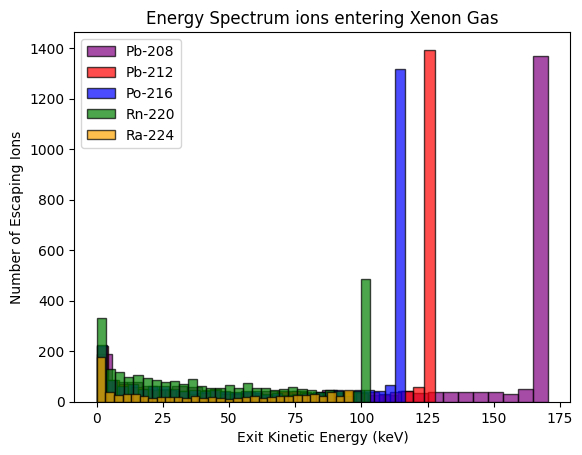

In [82]:
plt.hist(back_pb208['Energy_keV'], bins=30, color='purple', edgecolor='black', alpha=0.7, label='Pb-208')
plt.hist(back_pb212['Energy_keV'], bins=30, color='red', edgecolor='black', alpha=0.7, label='Pb-212')
plt.hist(back_po216['Energy_keV'], bins=30, color='blue', edgecolor='black', alpha=0.7, label='Po-216')
plt.hist(back_rn220['Energy_keV'], bins=30, color='green', edgecolor='black', alpha=0.7, label='Rn-220')
plt.hist(back_ra224['Energy_keV'], bins=30, color='orange', edgecolor='black', alpha=0.7, label='Ra-224')

plt.gca().set(xlabel='Exit Kinetic Energy (keV)', ylabel='Number of Escaping Ions', title='Energy Spectrum ions entering Xenon Gas')
plt.legend()

In [75]:
mean_energy_ra224 = np.mean(back_ra224['Energy_keV'].values)
mean_energy_rn220 = np.mean(back_rn220['Energy_keV'].values)
mean_energy_po216 = np.mean(back_po216['Energy_keV'].values)
mean_energy_pb212 = np.mean(back_pb212['Energy_keV'].values)
mean_energy_pb208 = np.mean(back_pb208['Energy_keV'].values)

mean_energy_dict = {
    'Ra-224': mean_energy_ra224,
    'Rn-220': mean_energy_rn220,
    'Po-216': mean_energy_po216,
    'Pb-212': mean_energy_pb212,
    'Pb-208': mean_energy_pb208
}

kinem_energy_dict = {
    'Ra-224': np.max(back_ra224['Energy_keV'].values),
    'Rn-220': np.max(back_rn220['Energy_keV'].values),
    'Po-216': np.max(back_po216['Energy_keV'].values),
    'Pb-212': np.max(back_pb212['Energy_keV'].values),
    'Pb-208': np.max(back_pb208['Energy_keV'].values)
}

print("Mean energy, correction factor")
for gen, mean_energy in mean_energy_dict.items():
    print(f"{gen}: {mean_energy:.2f}, {mean_energy / kinem_energy_dict[gen]:.6f}")
    

Mean energy, correction factor
Ra-224: 40.82, 0.422144
Rn-220: 48.49, 0.468913
Po-216: 78.36, 0.672601
Pb-212: 88.58, 0.692558
Pb-208: 117.50, 0.689142


# Assuming NO backscattering ions

Theoretical calculation of expected (relative) S2 areas:

$$ S2 = n_e \cdot g_2, $$
$$ n_e = N_i \cdot P_{\mathrm{surv}} (E_d, dE/dx) $$

$$ N_i = E_{EL} / W_i $$

$$E_{el} = E_R \cdot L(E_R)$$

where $E_R$ is the total Recoil kinetic energy, $L(E_R)$ is the Lindhard Factor, which we will approximate later, $E_{el}$ is the visible electronic stopping energy (the fraction that goest into stripping electrons from xenon atoms).

$W_i$ is the work function of xenon (22 eV), $P_{\mathrm{surv}} (E_d, dE/dx) $ is the recombination survival probability (in Jaffe or Birk's recombination models), and finally $g_2$ is the secondary gain constant of the detector.

But we can take $P_{\mathrm{surv}} (E_d, dE/dx) = 1 $ in the saturation regime (no recombination). And use a heuristic for low-energy Lindhard regime:

$$ L(E_R) \propto \sqrt(E_R) $$

And we take relative ratios with respect to the Th228 decay (Ra224 recoil), $S2_0$, so $W_i$ and $g_2$ factor out. Then:

$$ \frac{S2_i}{S2_0} \approx \left(\frac{E_{R,i}} {E_{R,0}}\right)^{1.5}



In [123]:
# mother_isotopes = ['Th228', 'Ra224', 'Rn220', 'Bi212', 'Po216', 'Po212']
mother_isotopes = ['Th228', 'Ra224', 'Rn220', 'Po216', 'Po212']

E_recoils = np.array([96.8, 103.4, 116.5, 127.9, 170.5])
s2_ratios = (E_recoils/E_recoils[0])**1.5

theoretical_values = {iso: ratio for iso, ratio in zip(mother_isotopes, s2_ratios)}
theoretical_values

{'Th228': np.float64(1.0),
 'Ra224': np.float64(1.1039966922363587),
 'Rn220': np.float64(1.3203098159148623),
 'Po216': np.float64(1.5187726953773377),
 'Po212': np.float64(2.3376179800637886)}

In [86]:
path_data = '/Volumes/KINGSTON/RaTag_data/processed/RUN50_EL27p5kVcm/isotope_areas/RUN_50_s2_vs_field_multiiso.csv'
df50 = pd.read_csv(path_data)

In [87]:
df_iso = {}
for iso in ['Th228', 'Ra224', 'Po216', 'Rn220', 'Bi212', 'Po212']:
    df_iso[iso] = {}
    df_iso[iso] = df50[df50['isotope'] == iso]

In [118]:
s2_max_th228 = df_iso['Th228']['s2_mean'].max()

means, ci95s = [], []
valid_keys = ['Th228', 'Ra224', 'Po216', 'Rn220', 'Po212']
for iso in valid_keys:
    mean = df_iso[iso]['s2_mean'].max() / s2_max_th228
    means.append(mean)
    ci95 = df_iso[iso]['s2_ci95'].max() / s2_max_th228
    ci95s.append(ci95)
s2_measured = pd.DataFrame({'isotope': list(valid_keys), 's2_mean': means, 's2_ci95': ci95s})
s2_measured

,isotope,s2_mean,s2_ci95
0,Th228,1.000000,0.039700
1,Ra224,1.158681,0.154922
2,Po216,1.363955,0.099100
3,Rn220,1.189263,0.063019
4,Po212,2.153418,0.326455


In [117]:
def get_s2_measured(path_data):
    df50 = pd.read_csv(path_data)
    df_iso = {}
    for iso in ['Th228', 'Ra224', 'Po216', 'Rn220', 'Bi212', 'Po212']:
        df_iso[iso] = {}
        df_iso[iso] = df50[df50['isotope'] == iso]
    s2_max_th228 = df_iso['Th228']['s2_mean'].max()

    means, ci95s = [], []
    valid_keys = ['Th228', 'Ra224', 'Po216', 'Rn220', 'Po212']
    for iso in valid_keys:
        mean = df_iso[iso]['s2_mean'].max() / s2_max_th228
        means.append(mean)
        ci95 = df_iso[iso]['s2_ci95'].max() / s2_max_th228
        ci95s.append(ci95)
    s2_measured = pd.DataFrame({'isotope': list(valid_keys), 's2_mean': means, 's2_ci95': ci95s})
    return s2_measured

In [91]:
for iso in theoretical_values.keys():
    print(f"{iso}: Theoretical S2 Ratio = {theoretical_values[iso]:.3f}, Measured S2 Ratio = {s2_measured[s2_measured['isotope'] == iso]['s2_mean'].values[0]:.3f}")

Th228: Theoretical S2 Ratio = 1.000, Measured S2 Ratio = 1.000
Ra224: Theoretical S2 Ratio = 1.104, Measured S2 Ratio = 1.159
Rn220: Theoretical S2 Ratio = 1.320, Measured S2 Ratio = 1.189
Po216: Theoretical S2 Ratio = 1.519, Measured S2 Ratio = 1.364
Po212: Theoretical S2 Ratio = 2.338, Measured S2 Ratio = 2.153


In [132]:
files_raw = ['/Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/RUN_43_s2_vs_field_multiiso.csv',
         '/Volumes/KINGSTON/RaTag_data/processed/RUN46_EL25kVcm/isotope_areas/RUN_46_s2_vs_field_multiiso.csv',
         '/Volumes/KINGSTON/RaTag_data/processed/RUN44_EL20kVcm/isotope_areas/RUN_44_s2_vs_field_multiiso.csv',
         '/Volumes/KINGSTON/RaTag_data/processed/RUN48_EL20kVcm/isotope_areas/RUN_48_s2_vs_field_multiiso.csv',
         '/Volumes/KINGSTON/RaTag_data/processed/RUN50_EL27p5kVcm/isotope_areas/RUN_50_s2_vs_field_multiiso.csv']
        #  '/Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/isotope_areas/RUN_51_s2_vs_field_multiiso.csv',]

s2_measured_list = []
run_names = []
for file in files_raw:
    s2_measured = get_s2_measured(file)
    s2_measured_list.append(s2_measured)
    run_names.append(file.split('/')[-1].split('_')[1])
run_names

['43', '46', '44', '48', '50']

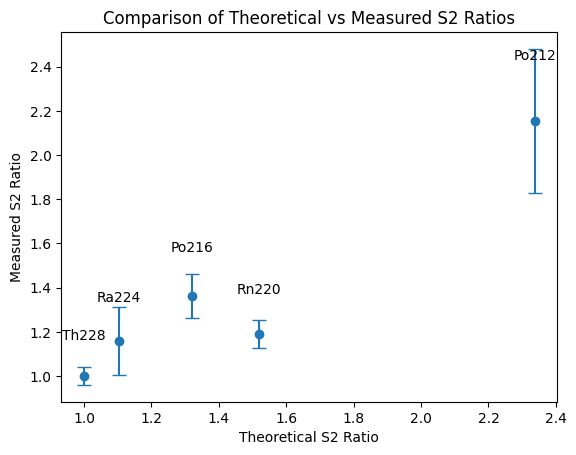

In [133]:
plt.errorbar(s2_ratios, s2_measured['s2_mean'], yerr=s2_measured['s2_ci95'], fmt='o', capsize=5)
plt.gca().set(xlabel='Theoretical S2 Ratio', ylabel='Measured S2 Ratio', title='Comparison of Theoretical vs Measured S2 Ratios')
for i, iso in enumerate(valid_keys):
    plt.annotate(iso, (s2_ratios[i], s2_measured['s2_mean'][i] * 1.1), textcoords="offset points", xytext=(0,10), ha='center')

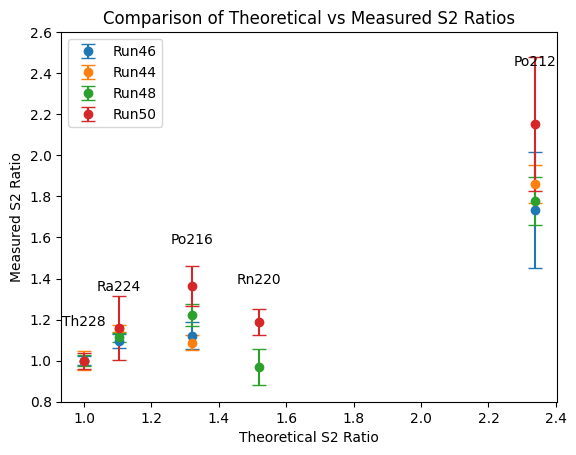

In [137]:
for i, s2_measured in enumerate(s2_measured_list[1:]):
    plt.errorbar(s2_ratios, s2_measured['s2_mean'], yerr=s2_measured['s2_ci95'], 
                 fmt='o', capsize=5, label='Run'+run_names[i+1])
plt.gca().set(xlabel='Theoretical S2 Ratio', ylim=(0.8, 2.6),
              ylabel='Measured S2 Ratio', title='Comparison of Theoretical vs Measured S2 Ratios')
for i, iso in enumerate(valid_keys):
    plt.annotate(iso, (s2_ratios[i], s2_measured['s2_mean'][i] * 1.1), textcoords="offset points", xytext=(0,10), ha='center')
plt.legend()
